### TODO:
COMENZAR YA CON EL MODELO DE DIFUSUION PARA AUDIO, PERO ANTES ARREGLAR LO DE LAS CAPAS DEL MODELO

In [1]:
%run init_notebook.py

import torch.nn as nn
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

import torchaudio.transforms as T
import math   
from src.dataset import NSynth
import torch
from src.diffusion import *
from src.utils.models import adjust_shape, compute_magnitude_and_phase


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = r"C:\Users\Articuno\Desktop\TFG-info\data\models\mod_diff.pth"
sch_path =  r"C:\Users\Articuno\Desktop\TFG-info\data\models\sch_diff.pth"
temp_path = r"C:\Users\Articuno\Desktop\TFG-info\data\models\temp_diff.pth"
sch_temp_path = r"C:\Users\Articuno\Desktop\TFG-info\data\models\temp_sch_diff.pth" 

In [2]:
@torch.no_grad()
def sample_images(model, scheduler, num_images=4, image_size=(1, 28, 28)):
    model.eval()

    x = torch.randn(num_images, *image_size, device=device)
    T = scheduler.beta.size(0)

    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar

    for t in reversed(range(T)):
        t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)

        # predicción de ruido
        e_pred = model(x, t_batch)
        
        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        
        # beta_t = beta_t.view(1,1,1,1)
        # alpha_t = alpha_t.view(1,1,1,1)
        # alpha_bar_t = alpha_bar_t.view(1,1,1,1)


        # Coeficientes DDPM
        coef1 = 1 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

        mu = coef1 * (x - coef2 * e_pred)

        if t > 0:
            noise = torch.randn_like(x)
            sigma_t = torch.sqrt(beta_t)
            x = mu + sigma_t * noise
        else:
            x = mu

    x = x.clamp(0, 1).cpu()

    # Mostrar imágenes
    fig, axes = plt.subplots(1, num_images, figsize=(num_images*2, 2))
    for i in range(num_images):
        axes[i].imshow(x[i, 0], cmap='gray')
        axes[i].axis('off')
    plt.show()

    return x

@torch.no_grad()
def remove_noise(model, scheduler, image_size=(1, 28, 28), x=None, alpha=0):
    model.eval()
    if x is None:
        x = torch.randn(1, *image_size, device=device)
        alpha = 1

    # Guardar imagen original
    x_original = x.clone().cpu()

    # Añadir ruido
    noise = torch.randn(1, *image_size, device=device) * (1 - alpha)
    x_noisy = x * alpha + noise
    x = x_noisy.clone()  # este será el tensor que pasaremos al DDPM

    T = scheduler.beta.size(0)
    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar

    for t in reversed(range(T)):
        t_batch = torch.full((1,), t, device=device, dtype=torch.long)
        e_pred = model(x, t_batch)
        
        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]

        coef1 = 1 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)
        mu = coef1 * (x - coef2 * e_pred)

        if t > 0:
            noise_step = torch.randn_like(x)
            sigma_t = torch.sqrt(beta_t)
            x = mu + sigma_t * noise_step
        else:
            x = mu

    x_denoised = x.clamp(0, 1).cpu()

    # Mostrar imágenes: original, con ruido, denoised
    fig, axes = plt.subplots(1, 3, figsize=(6, 2))
    axes[0].imshow(x_original[0, 0], cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(x_noisy[0, 0].cpu(), cmap='gray')
    axes[1].set_title('Noisy')
    axes[1].axis('off')

    axes[2].imshow(x_denoised[0, 0], cmap='gray')
    axes[2].set_title('Denoised')
    axes[2].axis('off')

    plt.show()

    return x_denoised



In [ ]:
def train(
    model, 
    stft_transform,
    epochs=1000, 
    batch_size=16, 
    lr=1e-3, 
    model_path=None,
    sch_path=None, 
    dataset=NSynth('training'), 
    verb=False
):
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,  pin_memory=True)
    scheduler = Scheduler(num_epochs=epochs, device=device).to(device)
    diffuser = Diffuser(model, scheduler).to(device)
    optimizer = torch.optim.Adam(diffuser.parameters(), lr=lr)
    
    mse_loss = nn.MSELoss()
    best_loss = 1
    losses = []
    
    for epoch in range(epochs):
        for wave, _, _, _ in train_loader:
            # wave = wave.to(device)
            # x = stft_transform(wave)
            
            wave = wave.to(device)
            stft_spec = stft_transform(wave)  
            mag, phase = compute_magnitude_and_phase(stft_spec)
            log_mag = torch.log1p(mag) 
            x = torch.cat([log_mag, phase], dim=1).to(device)
            batch_size = x.size(0)
            t = torch.randint(0, epochs, (batch_size,), device=device)

            with torch.cuda.amp.autocast(): # OPTIMIZACION LOAT 32
                z, e = diffuser(x, t)
                e_pred = model(z, t)
                loss = mse_loss(e_pred, e)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            #TODO borrar
            total_batches = len(train_loader)
            
            try:
                batch_idx += 1
                if batch_idx > total_batches:
                    batch_idx = 1
            except NameError:
                batch_idx = 1

            remaining = total_batches - batch_idx
            # print(f"Quedan {remaining} batches para esta ronda (batch {batch_idx}/{total_batches})")
            
                        
        losses.append(loss.item())
            
        if epoch % 10 == 0:
            if verb:
                print(f"Epoch {epoch}, Loss: {loss.item()}")
            
        if loss.item() < best_loss:
            best_loss = loss.item()
            if model_path is not None:
                torch.save(model.state_dict(), model_path)
                torch.save(scheduler.state_dict(), sch_path)
                if verb:
                    print(f"Model temporally saved at epoch {epoch} with loss {best_loss}")
            else:
                torch.save(model.state_dict(), temp_path)
                torch.save(scheduler.state_dict(), sch_temp_path)
                if verb:
                    print(f"Model saved at epoch {epoch} with loss {best_loss}")
    
    if model_path is not None:
        model.load_state_dict(torch.load(model_path))
        scheduler.load_state_dict(torch.load(sch_path))
    else:
        model.load_state_dict(torch.load(temp_path))
        scheduler.load_state_dict(torch.load(sch_temp_path))

        # eliminar temp?
        
    print("Training completed., best loss:", best_loss)
    
    return model, scheduler, losses
    

In [ ]:
# STFT transform
sample_rate = 16000
n_fft = 1500 #OPTIMIZACIONES 
hop_length = 250
win_length = n_fft
stft_transform = T.Spectrogram(
    n_fft=n_fft, win_length=win_length, hop_length=hop_length,
    power=None, onesided=False, center=False
).to(device)
istft_transform = T.InverseSpectrogram(
    n_fft=n_fft, win_length=win_length, hop_length=hop_length, onesided=False
).to(device)

# TRAIN SETUP
batch_size = 32*2
learning_rate = 1e-4
epochs = 50
train_loader = DataLoader(NSynth('training'), batch_size=batch_size, shuffle=True, pin_memory=True)
valid_loader = DataLoader(NSynth('validation'), batch_size=batch_size, shuffle=True, pin_memory=True)

# MODEL SETUP
input_height = 1500
input_width = 251
input_size = (input_height, input_width)
emb_dim = 128
norm_groups = 8


# layers
sin = sout = c = 128//8  # canal base, reducido para no explotar memoria
# TODO hacer que el tamaño dependa de n_ftt
down_layers = [
    DummyLayer(c,    c*2,  norm_groups, emb_dim, skip=True, stride=2).to(device),  # skip: c canales
    DummyLayer(c*2,  c*4,  norm_groups, emb_dim, skip=True, stride=2).to(device),  # skip: c*2 canales
    DummyLayer(c*4,  c*8,  norm_groups, emb_dim, skip=True, stride=2).to(device),  # skip: c*4 canales
    DummyLayer(c*8,  c*16, norm_groups, emb_dim, skip=True, stride=2).to(device),  # skip: c*8 canales
]

bottleneck = DummyLayer(c*16, c*16, norm_groups, emb_dim).to(device)

up_layers = [
    DummyLayer(c*16 + c*8,  c*8, norm_groups, emb_dim, size_out=(187, 31)).to(device),
    DummyLayer(c*8  + c*4,  c*4, norm_groups, emb_dim, size_out=(375, 62)).to(device),
    DummyLayer(c*4  + c*2,  c*2, norm_groups, emb_dim, size_out=(750, 125)).to(device),
    DummyLayer(c*2  + c,    c,   norm_groups, emb_dim, size_out=(1500, 251)).to(device),
]

# up_layers = [
#     DummyLayer(c*16 + c*8, c*8, norm_groups, emb_dim).to(device),
#     DummyLayer(c*8  + c*4, c*4, norm_groups, emb_dim).to(device),
#     DummyLayer(c*4  + c*2, c*2, norm_groups, emb_dim).to(device),
#     DummyLayer(c*2  + c,   c,   norm_groups, emb_dim).to(device),
# ]

# embeder
embedder = Embeder(num_epochs=epochs, embed_dim=emb_dim, device=device).to(device)

# scheduler
scheduler = Scheduler(num_epochs=epochs, device=device).to(device)

# model
model = DiffusionModel(
    layer_channels=(sin, sout),
    norm_groups=norm_groups,
    up_layers=up_layers,
    down_layers=down_layers,
    bottleneck=bottleneck,
    embedder=embedder,
    input_channels=2,
    output_channels=2
).to(device)


Quedan 2259 batches para esta ronda (batch 1/2260)
Quedan 2258 batches para esta ronda (batch 2/2260)
Quedan 2257 batches para esta ronda (batch 3/2260)
Quedan 2256 batches para esta ronda (batch 4/2260)
Quedan 2255 batches para esta ronda (batch 5/2260)
Quedan 2254 batches para esta ronda (batch 6/2260)
Quedan 2253 batches para esta ronda (batch 7/2260)
Quedan 2252 batches para esta ronda (batch 8/2260)
Quedan 2251 batches para esta ronda (batch 9/2260)
Quedan 2250 batches para esta ronda (batch 10/2260)
Quedan 2249 batches para esta ronda (batch 11/2260)
Quedan 2248 batches para esta ronda (batch 12/2260)
Quedan 2247 batches para esta ronda (batch 13/2260)
Quedan 2246 batches para esta ronda (batch 14/2260)
Quedan 2245 batches para esta ronda (batch 15/2260)
Quedan 2244 batches para esta ronda (batch 16/2260)
Quedan 2243 batches para esta ronda (batch 17/2260)
Quedan 2242 batches para esta ronda (batch 18/2260)
Quedan 2241 batches para esta ronda (batch 19/2260)
Quedan 2240 batches p

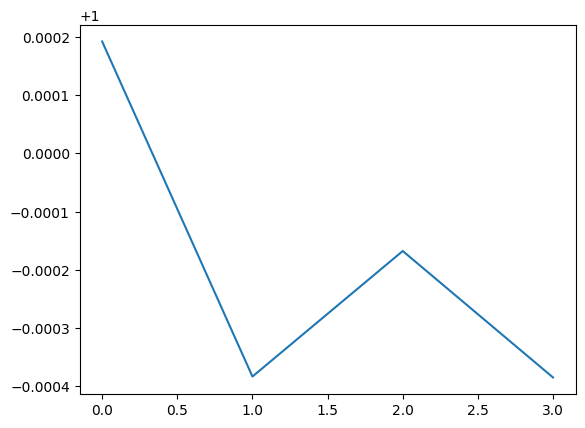

In [5]:
# %%timeç
# model = torch.compile(model)
model, scheduler, losses = train(
    model, 
    epochs=epochs,
    batch_size=batch_size, 
    lr=1e-3, 
    model_path=model_path, 
    sch_path=sch_path,
    dataset=NSynth('training'),
    verb=True,
    stft_transform=stft_transform
)
plt.plot(losses)

In [ ]:
@torch.no_grad()
def sample(model, scheduler, stft_transform, dataloader, shape, device, noise_level=0.5, steps=None):
    model.eval()
    steps = steps or len(scheduler.beta)
    
    wave, _, _, _ = next(iter(dataloader))
    wave = wave.to(device)
    stft_spec = stft_transform(wave[:shape[0]])
    log_mag, phase = compute_magnitude_and_phase(stft_spec)
    original = torch.cat([log_mag, phase], dim=1)  # (B, 2, F, T)
    
    t_noise = int(noise_level * (steps - 1))
    t_batch = torch.tensor([t_noise], device=device).expand(shape[0])
    _, _, alpha_bar_t = scheduler(t_batch)
    alpha_bar_t = alpha_bar_t.view(-1, 1, 1, 1)
    noise = torch.randn_like(original)
    x = torch.sqrt(alpha_bar_t) * original + torch.sqrt(1 - alpha_bar_t) * noise
    
    for t in reversed(range(t_noise + 1)):
        t_batch = torch.tensor([t], device=device).expand(shape[0])
        beta_t, alpha_t, alpha_bar_t = scheduler(t_batch)
        beta_t      = beta_t.view(-1, 1, 1, 1)
        alpha_t     = alpha_t.view(-1, 1, 1, 1)
        alpha_bar_t = alpha_bar_t.view(-1, 1, 1, 1)
        
        e_pred = model(x, t_batch)
        x = (1 / torch.sqrt(alpha_t)) * (x - (beta_t / torch.sqrt(1 - alpha_bar_t)) * e_pred)
        
        if t > 0:
            x = x + torch.sqrt(beta_t) * torch.randn_like(x)
    
    return x, original


def spec_to_audio(x, istft_transform):
    log_mag = x[:, 0]
    phase   = x[:, 1]
    magnitude    = torch.expm1(log_mag)
    spec_complex = magnitude * torch.exp(1j * phase)
    # print(f"dtype: {spec_complex.dtype}, device: {spec_complex.device}")
    return istft_transform(spec_complex)


def plot_spectrograms(original, generated):
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    for ax, spec, title in zip(axes, [original, generated], ['Original', 'Generado']):
        mag = spec[0, 0].cpu().numpy()
        im = ax.imshow(mag, origin='lower', aspect='auto', cmap='magma')
        ax.set_title(title)
        ax.set_xlabel('Tiempo')
        ax.set_ylabel('Frecuencia')
        plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def generate_audio(model, scheduler, stft_transform, istft_transform, device, noise_level=0.5, n_samples=1):
    dataloader = DataLoader(NSynth('validation'), batch_size=n_samples, shuffle=True, pin_memory=True)
    shape = (n_samples, 2, 1500, 251)
    
    x_denoised, original = sample(model, scheduler, stft_transform, dataloader, shape, device, noise_level=noise_level)
    
    audio_generated = spec_to_audio(x_denoised, istft_transform)
    audio_original  = spec_to_audio(original, istft_transform)
    
    plot_spectrograms(original, x_denoised)
    
    return audio_generated, audio_original

dtype: torch.complex64, device: cuda:0
dtype: torch.complex64, device: cuda:0


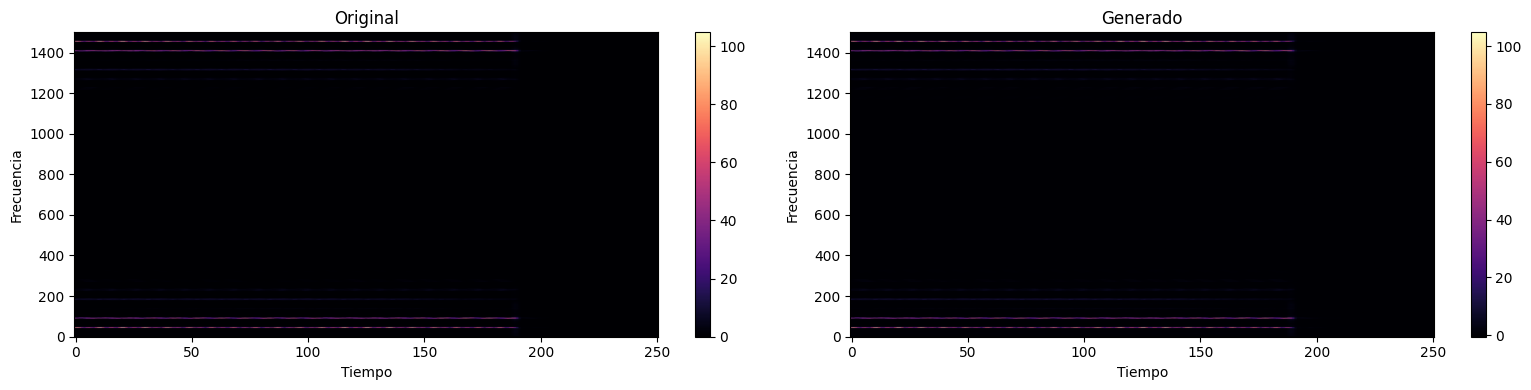

torch.Size([1, 62500])
dtype: torch.complex64, device: cuda:0


IndexError: tuple index out of range

In [ ]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
import torchaudio

audio, og = generate_audio(model, scheduler, stft_transform, istft_transform, device, n_samples=1)
# print(og.shape)

# tensor → numpy
audio_np = audio.squeeze().cpu().numpy()
og_np    = og.squeeze().cpu().numpy() if og.dim() == 1 else og[0, 0].cpu().numpy()

def plot_audio_spectrogram(audio_np, title):
    stft_out     = librosa.stft(audio_np, n_fft=512, hop_length=128)
    magnitude_db = librosa.amplitude_to_db(np.abs(stft_out), ref=np.max)
    librosa.display.specshow(magnitude_db, sr=sample_rate, hop_length=128, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)

# reconstruimos audio original desde og
og_audio = spec_to_audio(og, istft_transform)
og_np    = og_audio.squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plt.sca(axes[0])
plot_audio_spectrogram(og_np, 'Original')

plt.sca(axes[1])
plot_audio_spectrogram(audio_np, 'Generado')

plt.tight_layout()
plt.show()

# guardar audios
torchaudio.save("output_generated.wav", audio.squeeze(0).cpu(), sample_rate=sample_rate)
torchaudio.save("output_original.wav",  og_audio.squeeze(0).cpu(), sample_rate=sample_rate)